# Homework 3

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cmath
import scipy

j=complex(0,1) # imaginary unit

## Problem 1-d

Generation of the random wave function:

In [2]:
def random_state(N):
    
    # Generate a random amplitude for each coordinate:
    Amp=np.random.rand(2**N)
    
    # Normalize the amplitudes:
    Amp=Amp/np.linalg.norm(Amp) 

    # Generate a random phase for each coordinate:
    Phase=np.random.rand(2**N)*2*np.pi
    
    # Combine the amplitude and phase to get the complex coefficients:
    Coeff=Amp*np.exp(j*Phase) 
    
    # Reshape the coefficients into a 2^(N/2) x 2^(N/2) matrix:
    Coeff=np.reshape(Coeff,(2**(N//2),2**(N//2)))
    
    return Coeff

Histogram of the entanglement entropy of $N_{iter}$ samples for $4$ and $10$ spins and comparing it with the maximal value:

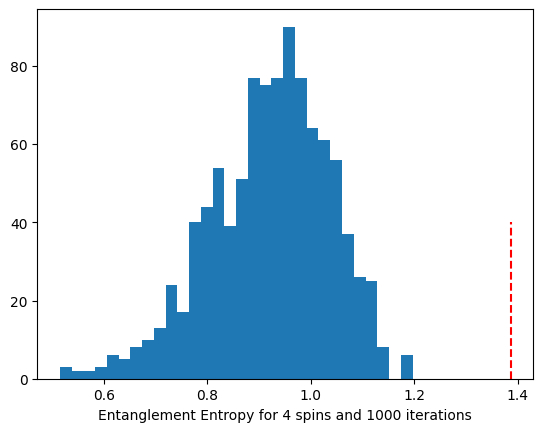

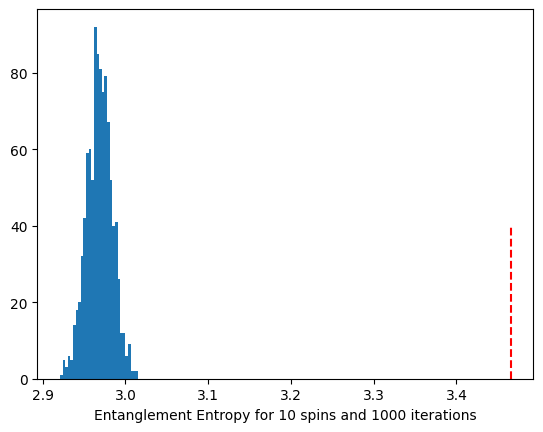

In [3]:

N_list=[4,10]  #Number of spins in the system (Hilbert space has dimension 2^N)

N_iter=1000 # number of random states to generate

for N in N_list:
    Entropies=[] # array to store the entropies

    for i in range(N_iter):

        Coeff=random_state(N) # generate a random state
        
        _,L,_=np.linalg.svd(Coeff) # singular value decomposition of the coefficient matrix
        
        S=-np.sum(L**2*np.log(L**2)) # von Neumann entropy
        
        Entropies.append(S)


    plt.hist(Entropies,bins=30)
    plt.vlines(N//2*np.log(2),0,40,colors='r',linestyles='dashed',label='Expected Value')
    plt.xlabel(f'Entanglement Entropy for {N} spins and {N_iter} iterations'.format(N=N))
    plt.show()



Averaging $S$ and plotting for different $N$ with errorbars:

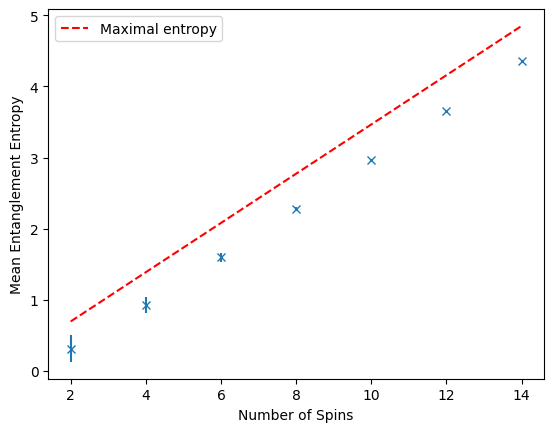

In [4]:

List_N=np.linspace(2,14,7,dtype=int) # list of N values to iterate over
N_iter=1000 # number of random states to generate
Entropies_mean=[] # array to store the mean entropies
Error_bars=[] # array to store the standard deviation of the entropies
for N in List_N:

    Entropies=[] # array to store the entropies

    for i in range(N_iter):

        Coeff=random_state(N) # generate a random state
        
        _,L,_=np.linalg.svd(Coeff) # singular value decomposition of the coefficient matrix
        S=-np.sum(L**2*np.log(L**2)) # von Neumann entropy
        Entropies.append(S)
      
    
    Entropies_mean.append(np.mean(Entropies))
    Error_bars.append(np.std(Entropies))


plt.errorbar(List_N,Entropies_mean,yerr=Error_bars,fmt='x')
plt.plot(List_N,np.log(2**(List_N//2)),'r--',label='Maximal entropy')
plt.xlabel('Number of Spins')
plt.ylabel('Mean Entanglement Entropy')
plt.legend()



## Question 2 - a

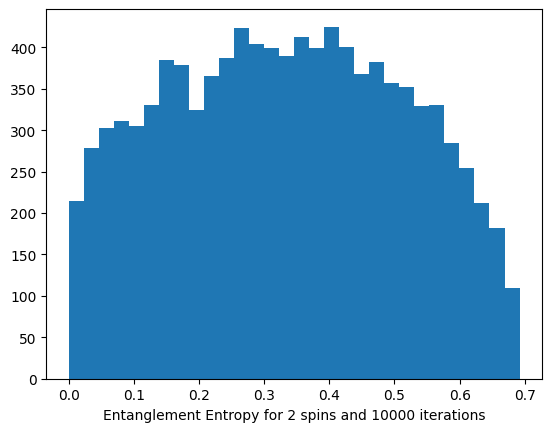

In [5]:
# Number of samples:
N_iter=10000

# Initial state vector for 2 spins (product state)
psi_0=np.array([[1],[0],[0],[0]],dtype=complex) 

# Vector to store the entropies of each sample:
Entropies=[]

for i in range(N_iter):

    # Generate a random 4x4 unitary matrix
    U = scipy.stats.unitary_group.rvs(4)

    # Apply the unitary transformation
    psi = np.dot(U, psi_0)

    # Density matrix of the state
    rho=np.dot(psi,psi.conj().T) 

    # Reshape the 4x4 matrix to a tensor with 4 indices (2 for each subsystem)
    rho=rho.reshape(2,2,2,2) 

    # Reduced density matrix for subsystem A (trace over subsystem B)
    rho_A=np.trace(rho,axis1=1,axis2=3) 

    # Computing entanglement entropy:
    eigvals = np.linalg.eigvalsh(rho_A) 

    S = -np.sum(eigvals * np.log(eigvals))

    # Storage:
    Entropies.append(S)


# Plotting the histogram of entropies:
plt.hist(Entropies,bins=30)

plt.xlabel(f'Entanglement Entropy for 2 spins and {N_iter} iterations'.format(N=2))

plt.show()


## Question 2 - b

Creating a function $random_unitary_layer(U,psi,i,j)$ that applies the unitary matrix $U$ on bond $(i,j)$ of the state $psi$: 

In [ ]:
def random_unitary_layer(U,psi,i,j):
       
    # Reshape the unitary matrix to act on two qubits
    U=np.reshape(U,(2,2,2,2)) 

    # Applying the tensor product:
    psi = np.tensordot(U, psi, axes=([0,1],[i,j]))

    return psi

Computing entanglement entropy versus time on $N_{iter}=20$ samples for $4, 8$ and $14$ spins:

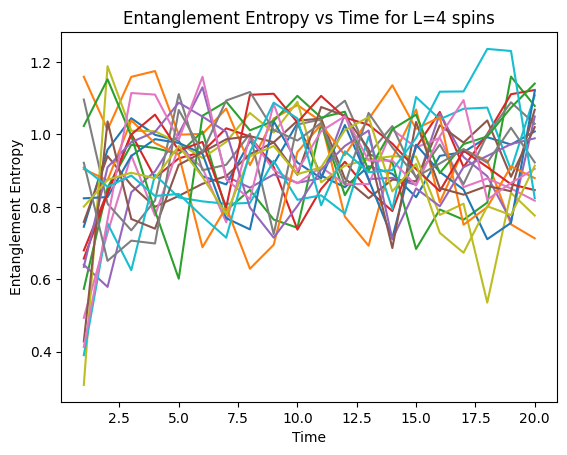

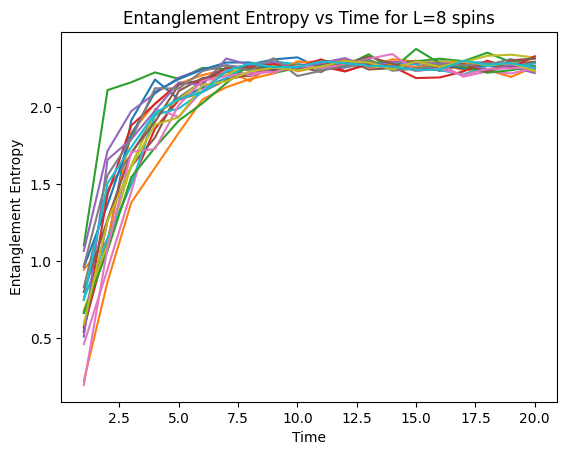

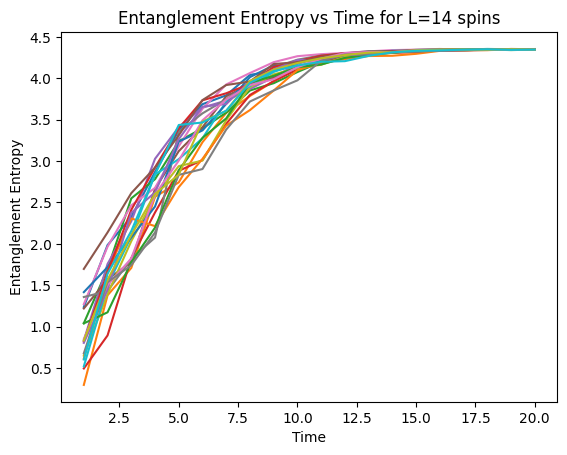

In [ ]:
#Number of spins:
L_list=[4,8,14]

#Maximum time steps:
t=20
T=np.linspace(1,t,t) # time array for plotting

#Number of different iterations for a given L and t:
N_iter=20


for L in L_list:
    for k in range(N_iter):

        S_t=[] # list to store the entropies at each time step

        # Initial state vector for L spins 
        psi_0=np.zeros((2**L,1),dtype=complex) 

        # Set the first element to 1 to create a product state
        psi_0[0]=1 

        # Representing the wave function as a tensor with L indices:
        psi = psi_0.reshape([2]*L)

        # Applying the layers of unitary transformations...
        for time in range(t):

            i,j=0,1

            #...on odd edges:
            while i<L-1:
                
                U = scipy.stats.unitary_group.rvs(4)

                psi = random_unitary_layer(U,psi,i,i+1)
            
                i += 2

            #...on even edges:
            while j<L-1:

                U = scipy.stats.unitary_group.rvs(4)
                
                psi = random_unitary_layer(U,psi,j,j+1)

                j += 2

            #Calculate the half-chain entanglement entropy using SVD:
            psi_mat = psi.reshape(2**(L//2), 2**(L//2))
            
            _,Sigma,_=np.linalg.svd(psi_mat) 
        
            S=-np.sum(Sigma**2*np.log(Sigma**2)) 

            # Adding value to the storing list:
            S_t.append(S)

        #Plotting iteration k+1 for a given L:
        plt.plot(T,S_t,label=f'Iteration {k+1}')



    #Graph parameters for a given L:
    plt.xlabel('Time')

    plt.ylabel('Entanglement Entropy')

    plt.title(f'Entanglement Entropy vs Time for L={L} spins')

    #plt.legend()
    plt.show()

Plotting $S_{\infty}$ versus number of spins and comparing with the random matrix theory prediction in question 1. $S_{\inf}$ is obained by taking the value at time $t=20$ averaged on $N_{iter}=50$ iterations:

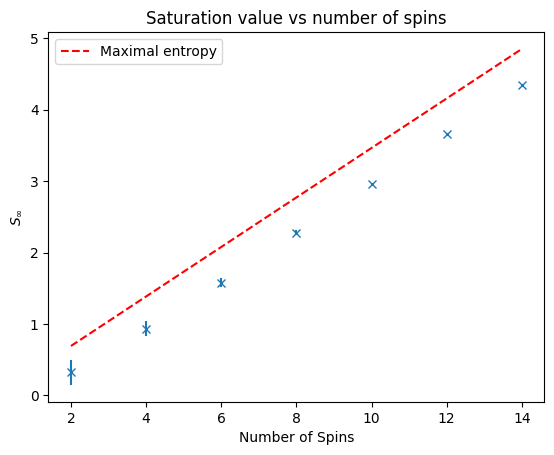

In [11]:
#Number of spins:
L_list=np.linspace(2,14,7,dtype=int)

#Maximum time steps:
t=20
T=np.linspace(1,t,t) # time array for plotting

#Number of different iterations for a given L and t:
N_iter=50

#List to store S_inf for each L:
S_L=[]
Err_bars=[]

for L in L_list:

    #List to store S_inf for each iteration at a given L:
    S_k=[]

    for k in range(N_iter):

        # Initial state vector for L spins 
        psi_0=np.zeros((2**L,1),dtype=complex) 

        # Set the first element to 1 to create a product state
        psi_0[0]=1 

        # Representing the wave function as a tensor with L indices:
        psi = psi_0.reshape([2]*L)

        # Applying the layers of unitary transformations...
        for time in range(t):

            i,j=0,1

            #...on odd edges:
            while i<L-1:
                
                U = scipy.stats.unitary_group.rvs(4)

                psi = random_unitary_layer(U,psi,i,i+1)
            
                i += 2

            #...on even edges:
            while j<L-1:

                U = scipy.stats.unitary_group.rvs(4)
                
                psi = random_unitary_layer(U,psi,j,j+1)

                j += 2

            # Adding value to the storing list:
            if time==t-1:

                #Calculate the half-chain entanglement entropy using SVD:
                psi = psi.reshape(2**(L//2), 2**(L//2))
                
                _,Sigma,_=np.linalg.svd(psi) 
            
                S=-np.sum(Sigma**2*np.log(Sigma**2)) 

                S_k.append(S)

    S_L.append(np.mean(S_k))
    Err_bars.append(np.std(S_k))





#Plotting S_inf vs L:
plt.errorbar(L_list,S_L,yerr=Err_bars,fmt='x')

plt.plot(L_list,np.log(2**(L_list//2)),'r--',label='Maximal entropy')

plt.ylabel(r'$S_{\infty}$')

plt.xlabel('Number of Spins')

plt.title(f'Saturation value vs number of spins')

plt.legend()


Compared with the graph plotted on question 1-d:

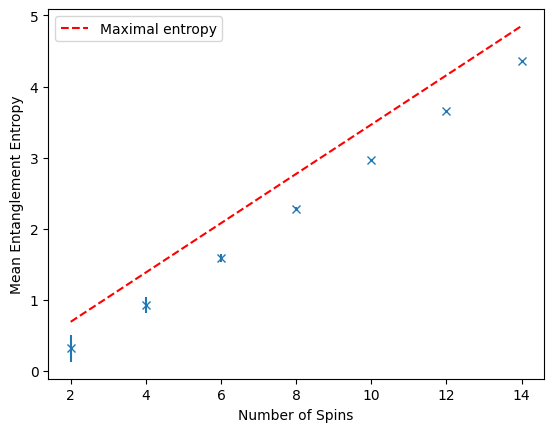